<a href="https://colab.research.google.com/github/Abdullah-ahfj/Abdullah-Portfolio/blob/master/DVSrpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

netflix_red = "#E50914"
netflix_black = "#141414"
netflix_gray = "#B3B3B3"
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


In [2]:
# Load Netflix dataset
df = pd.read_csv("netflix_titles.csv")

# Display first 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# data Inspection
# Column Overview
print("Column Names:")
print(df.columns.tolist())

# 2Dataset Dimensions
print("\nDataset Shape (Rows, Columns):")
print(df.shape)

# 3Missing Values Check
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Data Type Summary
print("\nData Types:")
print(df.dtypes)

# Duplicate Row Detection
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

# Unique Value Counts (for each column)
print("\nUnique Value Count per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

# Text Formatting Consistency (strip spaces for object columns)
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    df[col] = df[col].str.strip()

print("\nText formatting cleaned (leading/trailing spaces removed).")

# Preview of Data
print("\nPreview of Dataset:")
print(df.head())

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Dataset Shape (Rows, Columns):
(8807, 12)

Missing Values per Column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Number of Duplicate Rows:
0

Unique Value Count per Column:
show_id: 8807
type: 2
title: 8807
director: 4528
cast: 7692
country: 748
date_added: 1767
release_year: 74
rating: 17
duration: 220
listed_in: 514

In [4]:
# Data Cleaning

# Remove irrelevant columns (as mentioned in your report)
df.drop(columns=["cast", "description"], inplace=True)

# Handle Missing Values
df["director"] = df["director"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

# Drop rows where both director and country are missing originally
df.dropna(subset=["type", "title", "date_added", "release_year"], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert Date Added to datetime
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Extract year and month
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

# Filter between 2008–2021
df = df[(df["year_added"] >= 2008) & (df["year_added"] <= 2021)]

print("\nCleaned Dataset Shape:", df.shape)


Cleaned Dataset Shape: (8797, 12)


<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:18: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_475/3166945341.py:18: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+)")


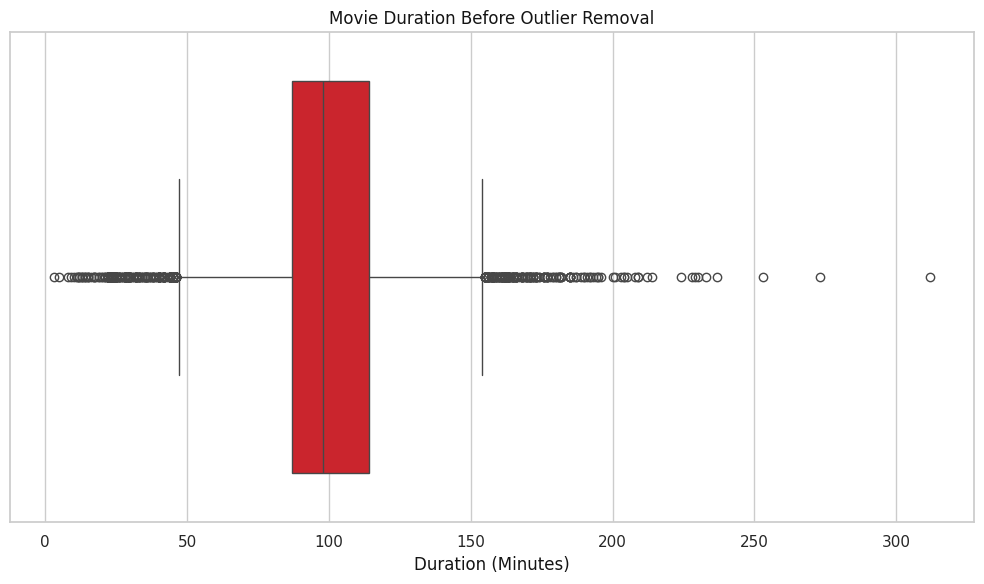

Number of Duration Outliers: 450


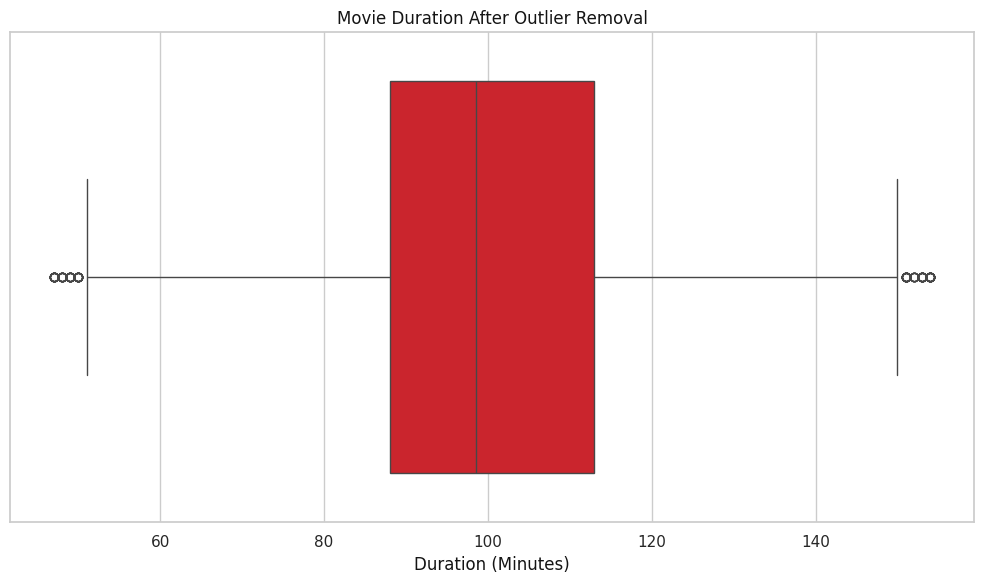

Shape After Removing Outliers: (5678, 14)


In [14]:
# Filter only movies
#befor cleaning the outliers
plt.figure()

sns.boxplot(x=df_movies["duration_minutes"],
            color=netflix_red)

plt.title("Movie Duration Before Outlier Removal", color=netflix_black)
plt.xlabel("Duration (Minutes)", color=netflix_black)

plt.tight_layout()
plt.show()
df_movies = df[df["type"] == "Movie"].copy()

# Extract numeric duration (remove "min")
df_movies["duration_minutes"] = (
    df_movies["duration"]
    .str.extract("(\d+)")
    .astype(float)
)

# Drop missing duration values (if any)
df_movies = df_movies.dropna(subset=["duration_minutes"])

# Calculate IQR
Q1 = df_movies["duration_minutes"].quantile(0.25)
Q3 = df_movies["duration_minutes"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df_movies[
    (df_movies["duration_minutes"] < lower_bound) |
    (df_movies["duration_minutes"] > upper_bound)
]

print("Number of Duration Outliers:", outliers.shape[0])

# Remove outliers
df_movies_clean = df_movies[
    (df_movies["duration_minutes"] >= lower_bound) &
    (df_movies["duration_minutes"] <= upper_bound)
]

#after cleaning the outliers
plt.figure()

sns.boxplot(x=df_movies_clean["duration_minutes"],
            color=netflix_red)

plt.title("Movie Duration After Outlier Removal", color=netflix_black)
plt.xlabel("Duration (Minutes)", color=netflix_black)

plt.tight_layout()
plt.show()

print("Shape After Removing Outliers:", df_movies_clean.shape)




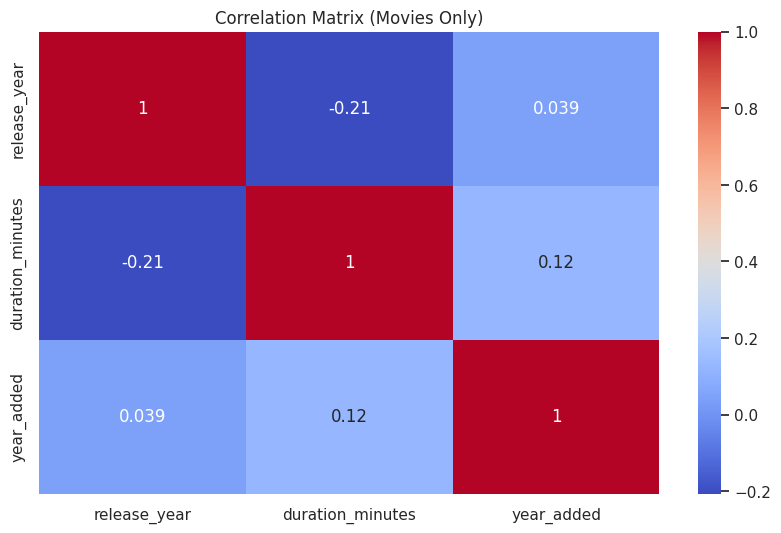


Correlation Matrix:
                  release_year  duration_minutes  year_added
release_year          1.000000         -0.206285    0.039351
duration_minutes     -0.206285          1.000000    0.124436
year_added            0.039351          0.124436    1.000000


In [6]:
# Correlation Analysis

numeric_df = df_movies[["release_year", "duration_minutes", "year_added"]]

correlation = numeric_df.corr()

plt.figure()
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix (Movies Only)")
plt.show()

print("\nCorrelation Matrix:")
print(correlation)

<>:91: SyntaxWarning: invalid escape sequence '\d'
<>:91: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_475/2061540218.py:91: SyntaxWarning: invalid escape sequence '\d'
  df_movies["duration"].str.extract("(\d+)").astype(float)


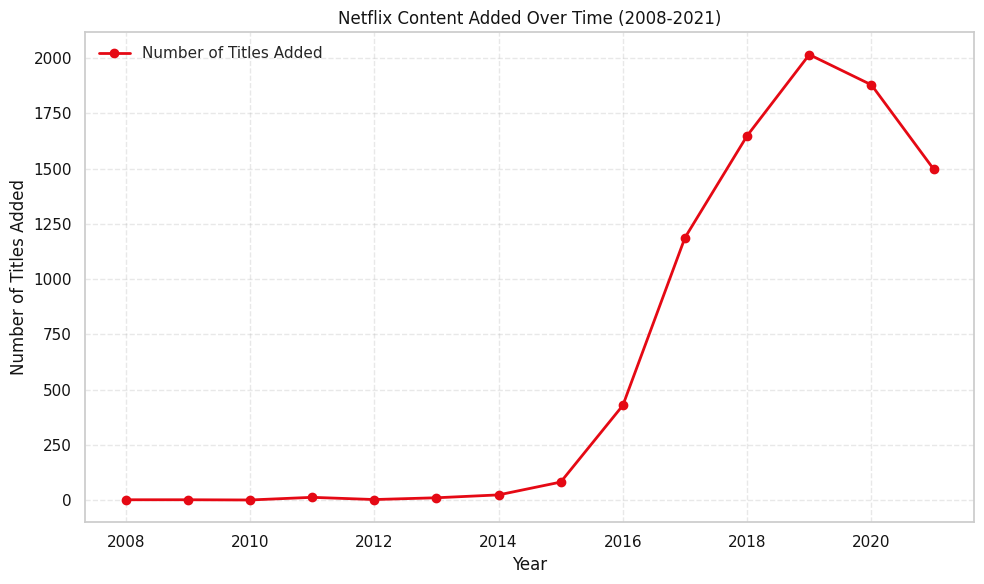

Peak Year for Content Addition: 2019


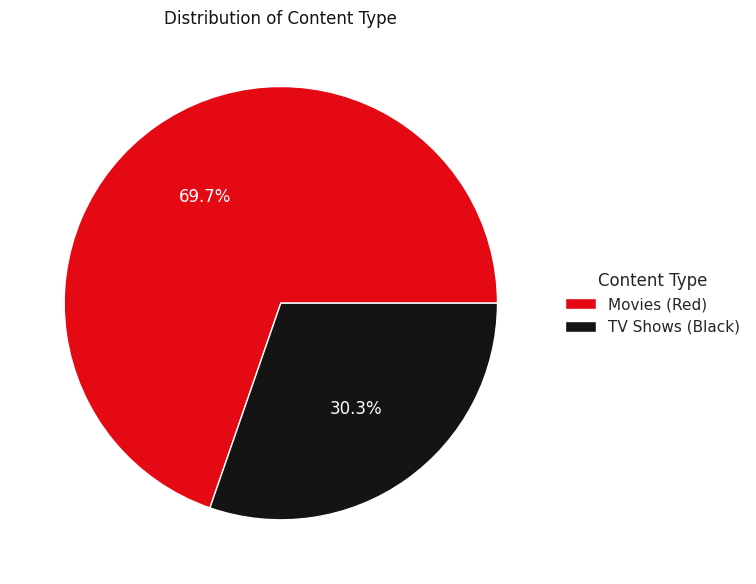

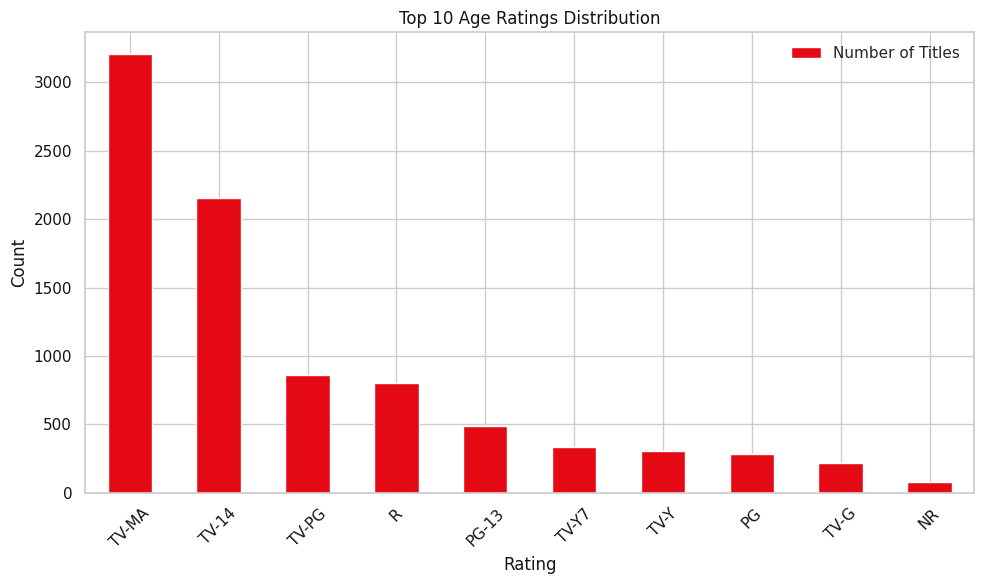

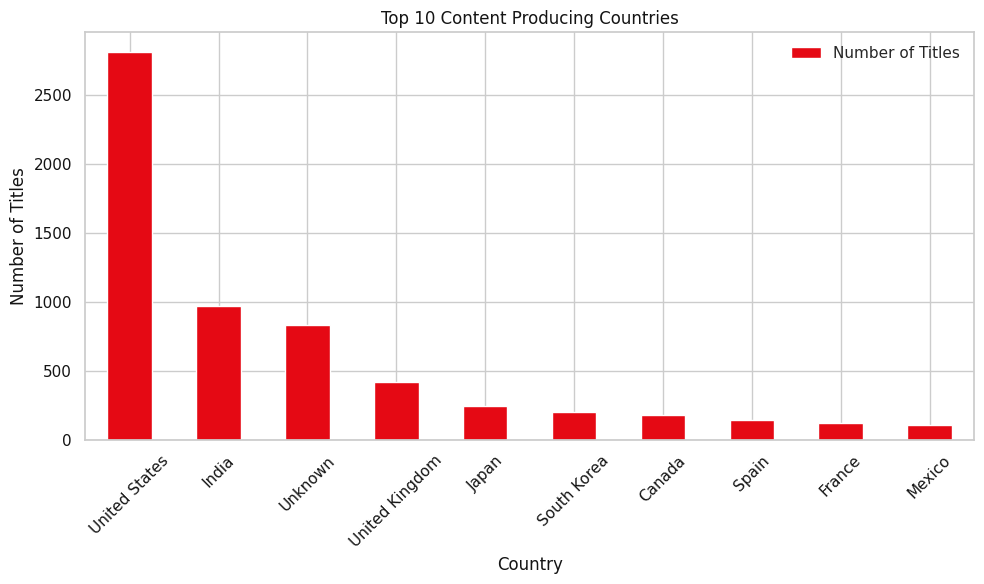

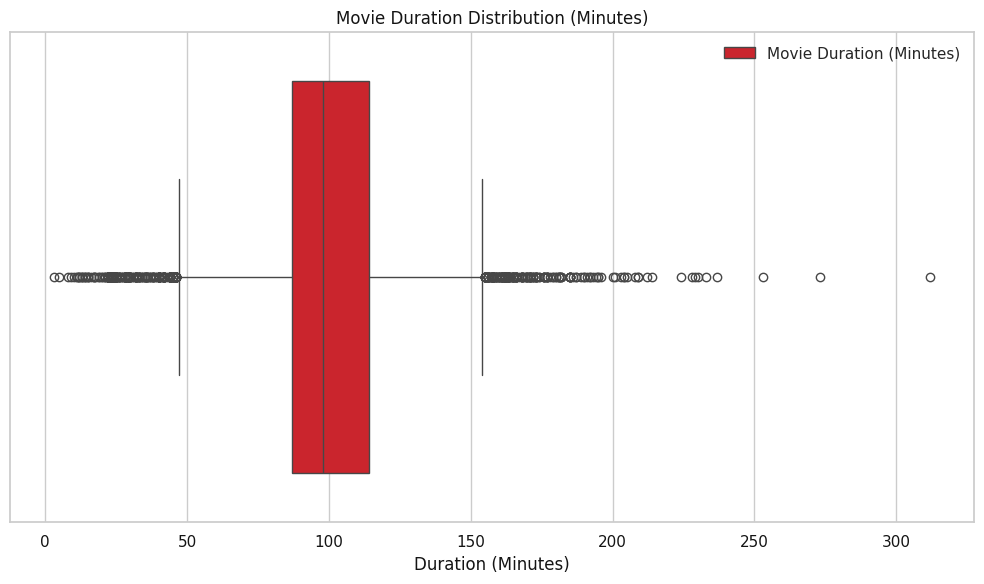

In [7]:

# EDA

# Content Growth Over Time

content_per_year = df["year_added"].value_counts().sort_index()

plt.figure()
plt.plot(content_per_year.index, content_per_year.values,
         marker='o', linewidth=2, color=netflix_red,
         label="Number of Titles Added")

plt.title("Netflix Content Added Over Time (2008-2021)", color=netflix_black)
plt.xlabel("Year", color=netflix_black)
plt.ylabel("Number of Titles Added", color=netflix_black)
plt.grid(color=netflix_gray, linestyle="--", alpha=0.3)

plt.xticks(color=netflix_black)
plt.yticks(color=netflix_black)

plt.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

print("Peak Year for Content Addition:", content_per_year.idxmax())


# Movie vs TV Show Distribution

type_counts = df["type"].value_counts()

plt.figure()
wedges, texts, autotexts = plt.pie(
    type_counts,
    autopct='%1.1f%%',
    colors=[netflix_red, netflix_black],
    textprops={'color': 'white'}
)

plt.title("Distribution of Content Type", color=netflix_black)

plt.legend(wedges,
           ["Movies (Red)", "TV Shows (Black)"],
           title="Content Type",
           loc="center left",
           bbox_to_anchor=(1, 0.5),
           frameon=False)

plt.tight_layout()
plt.show()


# Age Rating Distribution

rating_counts = df["rating"].value_counts().head(10)

plt.figure()
rating_counts.plot(kind="bar", color=netflix_red)

plt.title("Top 10 Age Ratings Distribution", color=netflix_black)
plt.xlabel("Rating", color=netflix_black)
plt.ylabel("Count", color=netflix_black)
plt.xticks(rotation=45, color=netflix_black)
plt.yticks(color=netflix_black)

plt.legend(["Number of Titles"], loc="upper right", frameon=False)
plt.tight_layout()
plt.show()


# Country Distribution

top_countries = df["country"].value_counts().head(10)

plt.figure()
top_countries.plot(kind="bar", color=netflix_red)

plt.title("Top 10 Content Producing Countries", color=netflix_black)
plt.xlabel("Country", color=netflix_black)
plt.ylabel("Number of Titles", color=netflix_black)
plt.xticks(rotation=45, color=netflix_black)
plt.yticks(color=netflix_black)

plt.legend(["Number of Titles"], loc="upper right", frameon=False)
plt.tight_layout()
plt.show()

# Duration Analysis (Movies Only)

df_movies = df[df["type"] == "Movie"].copy()
df_movies["duration_minutes"] = (
    df_movies["duration"].str.extract("(\d+)").astype(float)
)

plt.figure()
sns.boxplot(x=df_movies["duration_minutes"], color=netflix_red)

plt.title("Movie Duration Distribution (Minutes)", color=netflix_black)
plt.xlabel("Duration (Minutes)", color=netflix_black)
plt.xticks(color=netflix_black)

plt.legend(["Movie Duration (Minutes)"],
           loc="upper right",
           frameon=False)

plt.tight_layout()
plt.show()

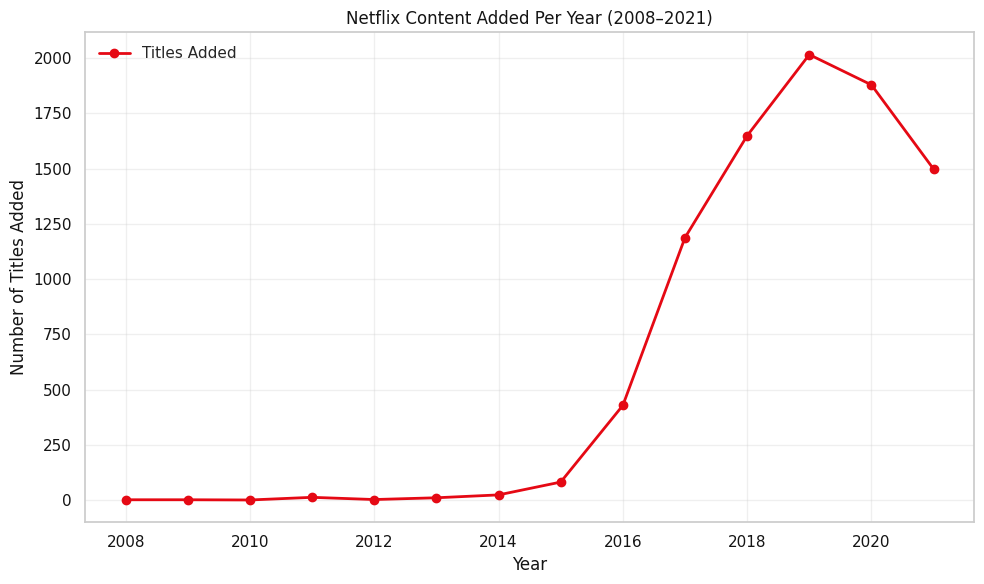

Peak Year for Content Addition: 2019


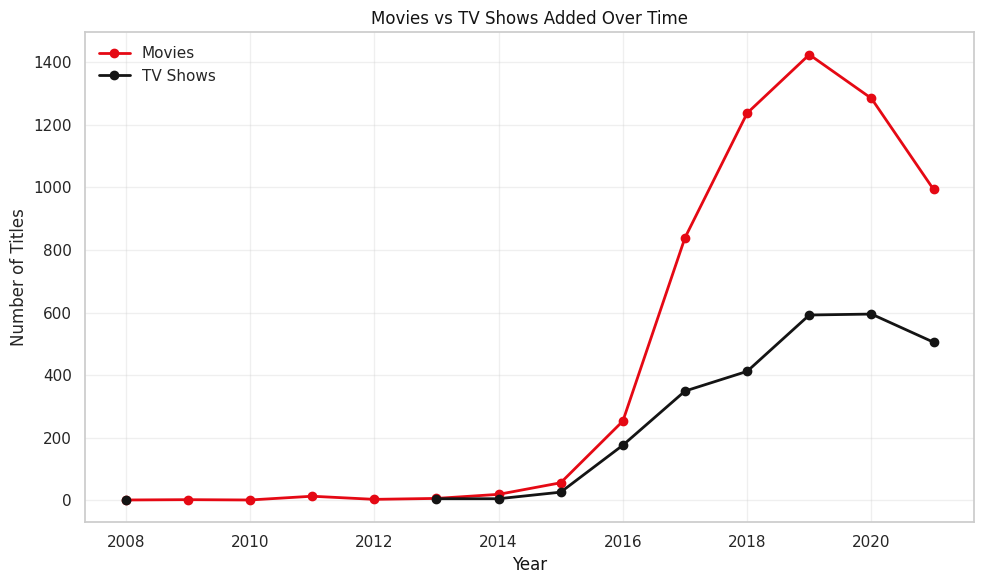

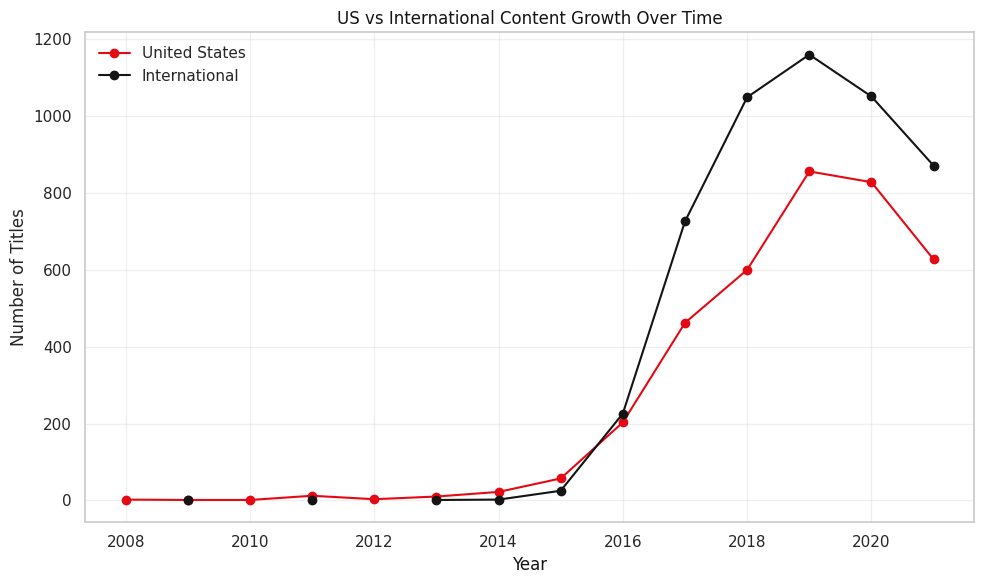

In [11]:
# Movies vs TV Shows Growth Over Time

type_year = df.groupby(["year_added", "type"]).size().unstack()

plt.figure()

plt.plot(type_year.index,
         type_year["Movie"],
         marker='o',
         linewidth=2,
         color=netflix_red,
         label="Movies")

plt.plot(type_year.index,
         type_year["TV Show"],
         marker='o',
         linewidth=2,
         color=netflix_black,
         label="TV Shows")

plt.title("Movies vs TV Shows Added Over Time", color=netflix_black)
plt.xlabel("Year", color=netflix_black)
plt.ylabel("Number of Titles")

plt.legend(loc="upper left", frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# US vs International Content Growth

df["is_us"] = df["country"].apply(
    lambda x: "United States" if isinstance(x, str) and "United States" in x else "International"
)

country_year = df.groupby(["year_added", "is_us"]).size().unstack()

plt.figure()

plt.plot(country_year.index,
         country_year["United States"],
         marker='o',
         color=netflix_red,
         label="United States")

plt.plot(country_year.index,
         country_year["International"],
         marker='o',
         color=netflix_black,
         label="International")

plt.title("US vs International Content Growth Over Time", color=netflix_black)
plt.xlabel("Year", color=netflix_black)
plt.ylabel("Number of Titles")

plt.legend(loc="upper left", frameon=False)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()